# Emergency Room Wait Time Analysis
## Identifying Operational Drivers of Patient Delays and Patient Satisfaction

### Business Problem

Emergency departments must balance patient volume, staffing levels, and quality of care while minimizing wait times. Long delays can negatively impact patient satisfaction and increase the likelihood of patients leaving without being seen.

This analysis examines emergency room visit data to identify the factors that contribute most to patient wait times and patient outcomes.

### Project Objectives

- Analyze emergency room wait times
- Identify peak demand periods
- Evaluate staffing impacts on operational efficiency
- Examine relationships between wait times and patient satisfaction
- Provide recommendations to improve patient flow

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df = pd.read_csv("er_wait_time_dataset.csv")

df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [3]:
df_work = df.copy()
df

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,HOSP-5-20241212-0989,PAT-04996,HOSP-5,Summit Health Center,Urban,2024-12-12 04:29:36,Thursday,Winter,Evening,Critical,2,1,142,6,10,19,35,Discharged,3
4996,HOSP-4-20240630-0995,PAT-04997,HOSP-4,St. Mary’s Regional Health,Rural,2024-06-30 22:44:17,Sunday,Summer,Evening,Medium,4,0,19,7,23,40,70,Discharged,3
4997,HOSP-2-20240213-1022,PAT-04998,HOSP-2,Riverside Medical Center,Urban,2024-02-13 21:06:17,Tuesday,Winter,Afternoon,Medium,3,7,163,14,29,87,130,Discharged,1
4998,HOSP-2-20240828-1023,PAT-04999,HOSP-2,Riverside Medical Center,Urban,2024-08-28 03:11:51,Wednesday,Summer,Afternoon,Low,5,4,160,21,35,73,129,Left Without Being Seen,1


In [4]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [5]:
display(df)

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1
5,HOSP-5-20241120-0001,PAT-00006,HOSP-5,Summit Health Center,Urban,2024-11-20 22:34:08,Wednesday,Fall,Night,Medium,3,7,167,12,15,36,63,Discharged,3
6,HOSP-3-20240221-0003,PAT-00007,HOSP-3,Northside Community Hospital,Rural,2024-02-21 15:26:54,Wednesday,Winter,Late Morning,Medium,4,2,42,22,37,57,116,Admitted,1
7,HOSP-2-20241212-0002,PAT-00008,HOSP-2,Riverside Medical Center,Urban,2024-12-12 20:23:38,Thursday,Winter,Afternoon,Medium,3,2,84,8,25,48,81,Admitted,2
8,HOSP-1-20241129-0003,PAT-00009,HOSP-1,Springfield General Hospital,Urban,2024-11-29 02:47:33,Friday,Fall,Afternoon,Medium,4,3,87,16,27,35,78,Discharged,2
9,HOSP-1-20240727-0004,PAT-00010,HOSP-1,Springfield General Hospital,Urban,2024-07-27 22:01:14,Saturday,Summer,Afternoon,Critical,1,4,99,3,3,5,11,Admitted,5


## Data Inspection

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [7]:
df.shape

(5000, 19)

In [8]:
df.columns

Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction'],
      dtype='object')

In [9]:
df.isnull().sum()

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

In [10]:
df.describe()

,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,2.771600
std,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,1.424584
min,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,3.000000
75%,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,4.000000
max,5.000000,10.000000,200.000000,66.000000,163.000000,233.000000,442.000000,5.000000


In [11]:
df_work['Visit Date'] = pd.to_datetime(df_work['Visit Date'])

In [12]:
df_work['Visit Date'].head()

0   2024-02-10 20:20:56
1   2024-11-28 02:07:47
2   2024-09-30 04:02:28
3   2024-02-27 00:31:13
4   2024-03-06 16:52:26
Name: Visit Date, dtype: datetime64[ns]

## Executive Summary Metrics

In [13]:
avg_wait = df_work['Total Wait Time (min)'].mean()

avg_satisfaction = df_work['Patient Satisfaction'].mean()

total_visits = len(df_work)

left_without_seen = (
    df_work['Patient Outcome']
    .eq('Left Without Being Seen')
    .mean() * 100
)

print(f"Average Wait Time: {avg_wait:.2f} minutes")
print(f"Average Satisfaction: {avg_satisfaction:.2f}")
print(f"Total Visits: {total_visits}")
print(f"Left Without Being Seen: {left_without_seen:.2f}%")

Average Wait Time: 81.92 minutes
Average Satisfaction: 2.77
Total Visits: 5000
Left Without Being Seen: 5.06%


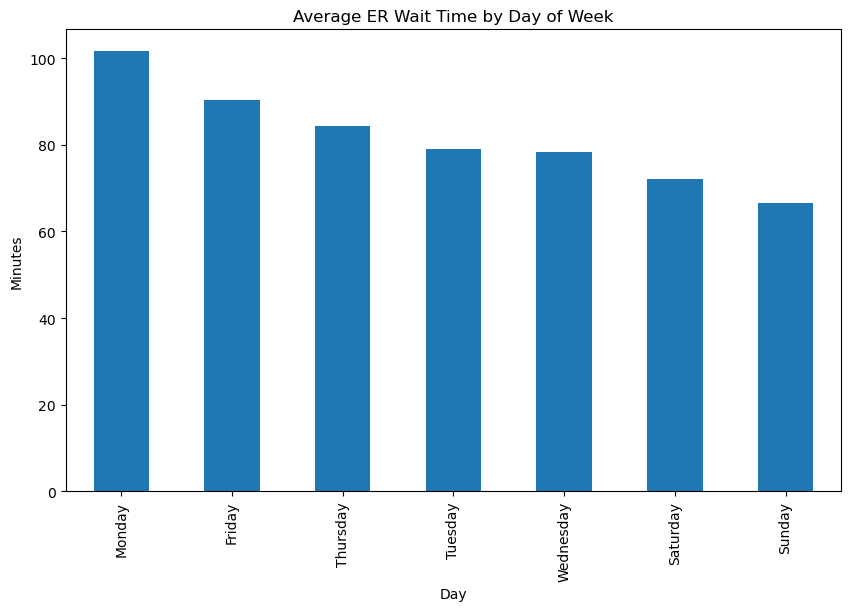

In [14]:
wait_by_day = (
    df_work.groupby('Day of Week')
    ['Total Wait Time (min)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

wait_by_day.plot(kind='bar')

plt.title('Average ER Wait Time by Day of Week')
plt.ylabel('Minutes')
plt.xlabel('Day')

plt.show()

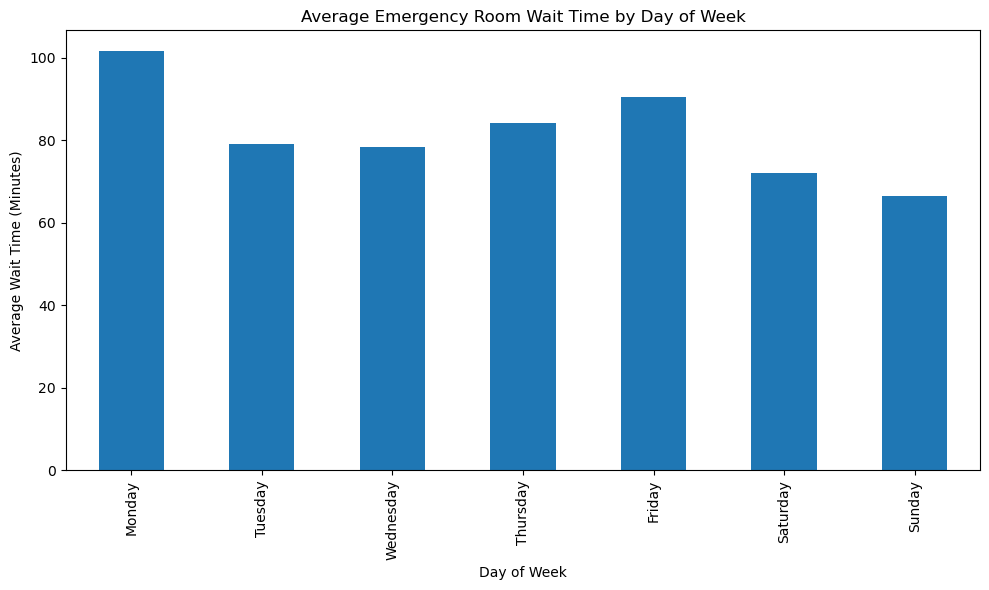

In [15]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

wait_by_day = (
    df_work.groupby('Day of Week')['Total Wait Time (min)']
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10,6))

wait_by_day.plot(kind='bar')

plt.title('Average Emergency Room Wait Time by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Wait Time (Minutes)')

plt.tight_layout()

plt.show()

## Wait Time by Urgency Level

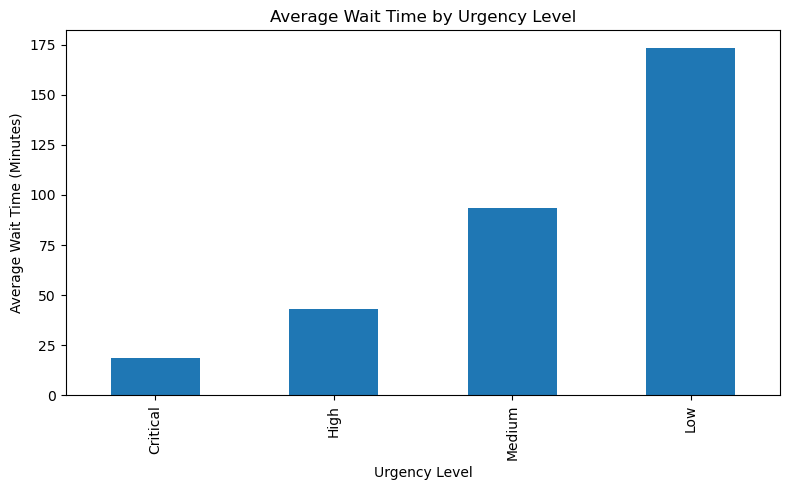

In [16]:
wait_by_urgency = (
    df_work.groupby('Urgency Level')
    ['Total Wait Time (min)']
    .mean()
)

wait_by_urgency = wait_by_urgency.reindex(
    ['Critical','High','Medium','Low']
)

plt.figure(figsize=(8,5))

wait_by_urgency.plot(kind='bar')

plt.title('Average Wait Time by Urgency Level')
plt.xlabel('Urgency Level')
plt.ylabel('Average Wait Time (Minutes)')

plt.tight_layout()

plt.show()

## Critical patients were prioritized and received significantly faster treatment compared to low-priority patients, demonstrating effective triage procedures.

### Key Finding

Critical patients experienced the shortest wait times, averaging approximately 20 minutes, while low-priority patients waited nearly 173 minutes on average. This suggests that triage procedures effectively prioritized patients based on medical urgency, ensuring the most severe cases received treatment first.

## Staffing Impact on Wait Times

In [17]:
staffing_wait = (
    df_work.groupby('Nurse-to-Patient Ratio')
    ['Total Wait Time (min)']
    .mean()
)

staffing_wait

Nurse-to-Patient Ratio
1     16.076923
2     20.745455
3     63.704460
4    107.340000
5    172.122835
Name: Total Wait Time (min), dtype: float64

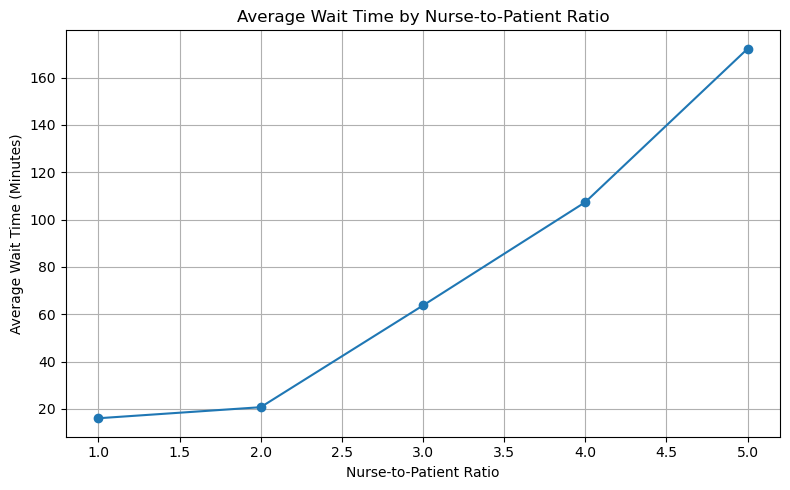

In [18]:
plt.figure(figsize=(8,5))

staffing_wait.plot(kind='line', marker='o')

plt.title('Average Wait Time by Nurse-to-Patient Ratio')
plt.xlabel('Nurse-to-Patient Ratio')
plt.ylabel('Average Wait Time (Minutes)')

plt.grid(True)

plt.tight_layout()

plt.show()

### Key Finding

Emergency room wait times increased significantly as nurse-to-patient ratios rose. Facilities operating at a ratio of 1 experienced average wait times of approximately 16 minutes, while facilities operating at a ratio of 5 experienced wait times exceeding 170 minutes.

This suggests staffing levels are a critical operational driver of emergency room efficiency and patient access to care.

## Relationship Between Wait Time and Patient Satisfaction

In [19]:
satisfaction_wait = (
    df_work.groupby('Patient Satisfaction')
    ['Total Wait Time (min)']
    .mean()
)

satisfaction_wait

Patient Satisfaction
1    167.537711
2     88.747107
3     57.757159
4     27.697691
5     14.803604
Name: Total Wait Time (min), dtype: float64

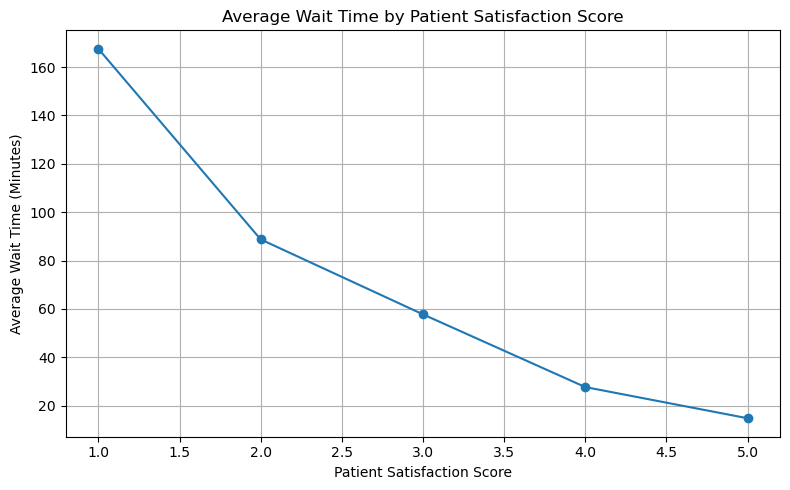

In [20]:
plt.figure(figsize=(8,5))

satisfaction_wait.plot(kind='line', marker='o')

plt.title('Average Wait Time by Patient Satisfaction Score')
plt.xlabel('Patient Satisfaction Score')
plt.ylabel('Average Wait Time (Minutes)')

plt.grid(True)

plt.tight_layout()

plt.show()

### Key Finding

Patient satisfaction decreased significantly as wait times increased. Patients reporting the highest satisfaction scores experienced average wait times of approximately 15 minutes, while patients reporting the lowest satisfaction scores waited more than 160 minutes on average.

This finding suggests that reducing emergency room wait times could have a substantial positive impact on overall patient experience and satisfaction.

## Patients Leaving Without Being Seen

In [21]:
lwbs_wait = (
    df_work.groupby('Patient Outcome')
    ['Total Wait Time (min)']
    .mean()
)

lwbs_wait

Patient Outcome
Admitted                    48.654711
Discharged                  94.962487
Left Without Being Seen    179.047431
Name: Total Wait Time (min), dtype: float64

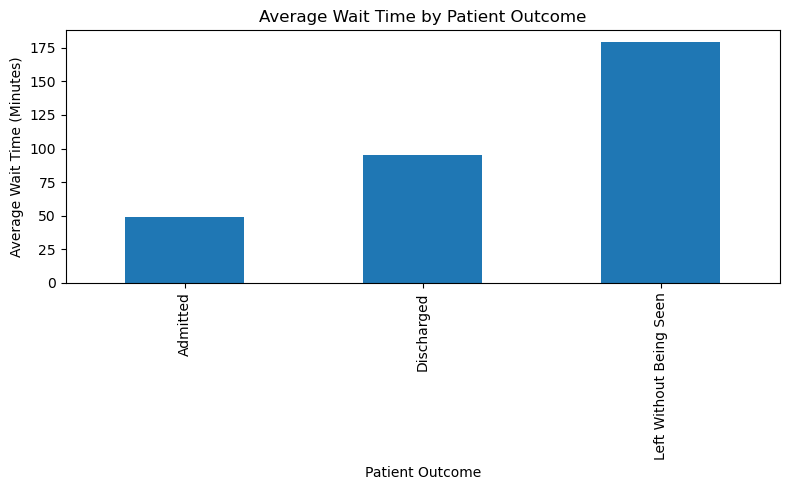

In [22]:
plt.figure(figsize=(8,5))

lwbs_wait.sort_values().plot(kind='bar')

plt.title('Average Wait Time by Patient Outcome')
plt.xlabel('Patient Outcome')
plt.ylabel('Average Wait Time (Minutes)')

plt.tight_layout()

plt.show()

### Key Finding

Patients who left the emergency room without being seen experienced the longest average wait times, exceeding 175 minutes. In comparison, admitted patients waited approximately 50 minutes on average, while discharged patients waited roughly 95 minutes.

This suggests that excessive wait times are a major contributor to patients leaving before receiving care. Reducing wait times may improve patient retention, patient outcomes, and overall emergency department performance.

## Peak Demand Analysis

In [23]:
visit_volume = (
    df_work['Time of Day']
    .value_counts()
)

visit_volume

Time of Day
Evening          1725
Afternoon        1502
Late Morning      770
Night             530
Early Morning     473
Name: count, dtype: int64

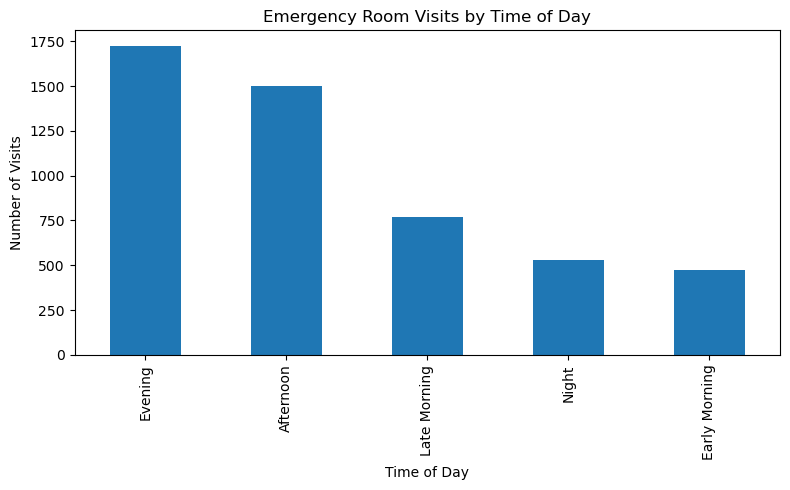

In [24]:
plt.figure(figsize=(8,5))

visit_volume.plot(kind='bar')

plt.title('Emergency Room Visits by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Visits')

plt.tight_layout()

plt.show()

### Key Finding

Emergency room demand peaked during afternoon and evening hours, accounting for the highest patient volumes in the dataset. Early morning periods experienced significantly lower visit counts.

These findings suggest that staffing resources should be strategically allocated during afternoon and evening periods to better manage patient flow and reduce wait times.

## Seasonal Trends

In [25]:
season_visits = (
    df_work['Season']
    .value_counts()
)

season_visits

Season
Summer    1281
Winter    1258
Fall      1234
Spring    1227
Name: count, dtype: int64

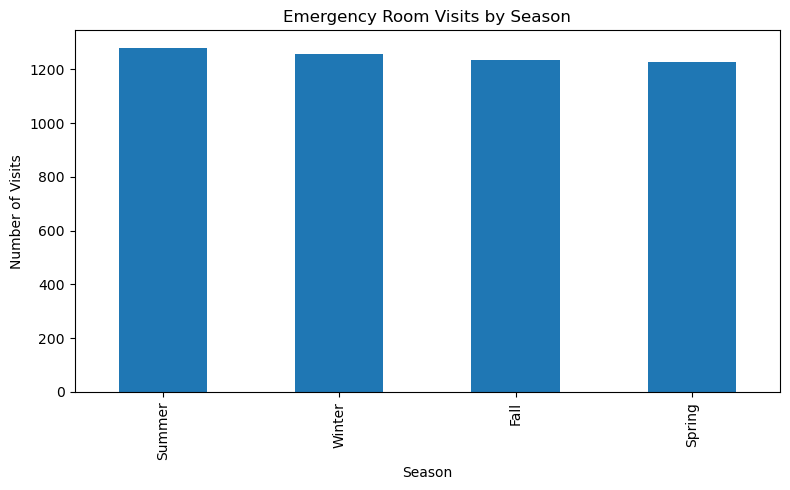

In [26]:
plt.figure(figsize=(8,5))

season_visits.plot(kind='bar')

plt.title('Emergency Room Visits by Season')
plt.xlabel('Season')
plt.ylabel('Number of Visits')

plt.tight_layout()

plt.show()

### Key Finding

Patient volumes remained relatively consistent across all seasons, with only minor fluctuations observed throughout the year. While Summer and Winter experienced slightly higher visit counts, no season demonstrated a substantial increase in demand.

This suggests emergency departments must maintain operational readiness year-round rather than relying solely on seasonal staffing adjustments.

## Specialist Availability and Wait Times

In [27]:
specialist_wait = (
    df_work.groupby('Specialist Availability')
    ['Total Wait Time (min)']
    .mean()
)

specialist_wait.head()

Specialist Availability
0    77.157895
1    79.142857
2    83.040100
3    88.853155
4    80.627692
Name: Total Wait Time (min), dtype: float64

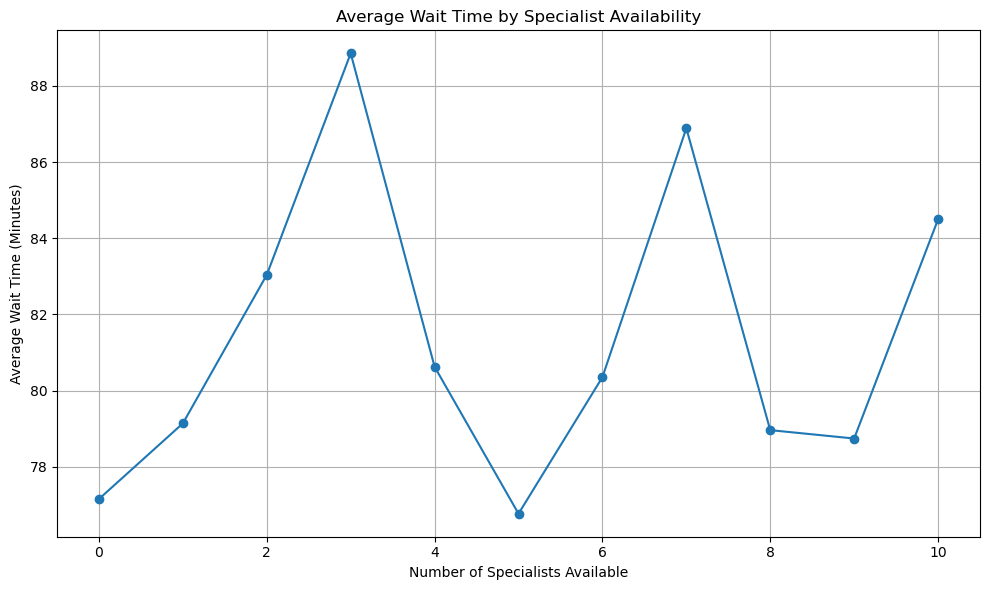

In [28]:
plt.figure(figsize=(10,6))

specialist_wait.plot(kind='line', marker='o')

plt.title('Average Wait Time by Specialist Availability')
plt.xlabel('Number of Specialists Available')
plt.ylabel('Average Wait Time (Minutes)')

plt.grid(True)

plt.tight_layout()

plt.show()

## Executive Summary

This analysis examined 5,000 emergency room visits to identify operational drivers of patient wait times, patient satisfaction, and visit outcomes.

Key findings revealed that:

- Mondays experienced the highest average wait times.
- Critical patients received significantly faster treatment than low-priority patients.
- Higher nurse-to-patient ratios were associated with substantially longer wait times.
- Longer wait times resulted in lower patient satisfaction scores.
- Patients leaving without being seen experienced the longest delays.

## Recommendations

1. Increase staffing during afternoon and evening peak periods.

2. Monitor nurse-to-patient ratios to reduce patient delays.

3. Improve patient flow processes for low-priority cases.

4. Increase specialist availability during high-volume periods.

5. Develop strategies to reduce patients leaving without being seen.

In [29]:
corr_columns = [
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)',
    'Total Wait Time (min)',
    'Patient Satisfaction'
]

corr_matrix = df_work[corr_columns].corr()

corr_matrix

,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
Nurse-to-Patient Ratio,1.000000,0.002511,0.002937,0.652054,0.646690,0.673622,0.688015,-0.738991
Specialist Availability,0.002511,1.000000,0.503209,0.006500,-0.000512,0.011028,0.006579,-0.014892
Facility Size (Beds),0.002937,0.503209,1.000000,0.003402,-0.012659,0.000980,-0.003578,-0.010528
Time to Registration (min),0.652054,0.006500,0.003402,1.000000,0.857030,0.876695,0.924238,-0.825610
Time to Triage (min),0.646690,-0.000512,-0.012659,0.857030,1.000000,0.875145,0.953604,-0.795599
Time to Medical Professional (min),0.673622,0.011028,0.000980,0.876695,0.875145,1.000000,0.976446,-0.857626
Total Wait Time (min),0.688015,0.006579,-0.003578,0.924238,0.953604,0.976446,1.000000,-0.865145
Patient Satisfaction,-0.738991,-0.014892,-0.010528,-0.825610,-0.795599,-0.857626,-0.865145,1.000000


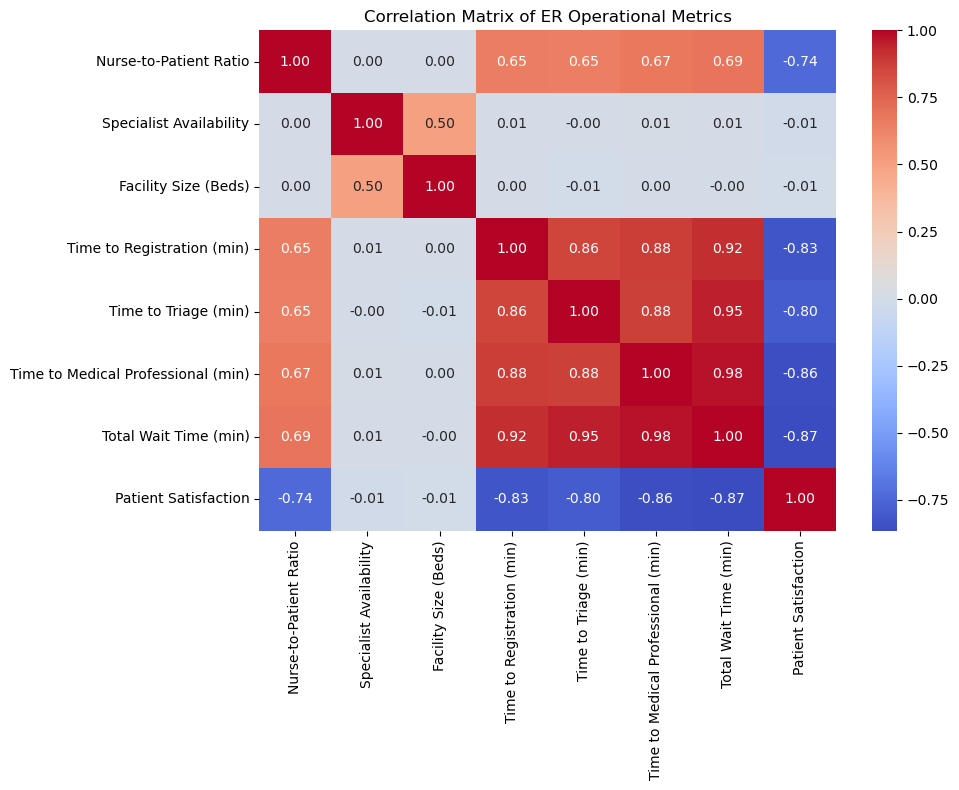

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of ER Operational Metrics')

plt.tight_layout()

plt.show()

## Correlation Analysis

The correlation analysis revealed several strong relationships among operational metrics.

Key findings include:

- Total wait time and patient satisfaction demonstrated a strong negative correlation (-0.87), indicating that longer waits significantly reduce patient satisfaction.

- Time to registration, triage, and medical professional assessment all exhibited strong positive correlations with total wait time, suggesting delays throughout the patient journey contribute to overall patient wait experiences.

- Nurse-to-patient ratios showed a positive correlation with total wait time (0.69), supporting previous findings that staffing levels play an important role in emergency department efficiency.

These findings reinforce the importance of operational improvements focused on staffing, patient flow, and reducing bottlenecks throughout the emergency care process.

# Conclusion & Strategic Implications

This analysis examined 5,000 emergency room visits to identify the operational factors influencing patient wait times, satisfaction, and visit outcomes.

Several important patterns emerged:

- Mondays experienced the highest average wait times.

- Critical patients were appropriately prioritized and received significantly faster care.

- Higher nurse-to-patient ratios were associated with longer wait times.

- Longer wait times strongly reduced patient satisfaction.

- Patients who left without being seen experienced the longest delays.

- Afternoon and evening periods represented the highest demand periods.

The findings suggest that staffing levels and operational bottlenecks throughout the patient journey significantly influence emergency department performance.

Strategic improvements focused on staffing optimization, patient flow management, and reducing delays in registration, triage, and provider access could improve patient satisfaction while reducing the likelihood of patients leaving before receiving care.

These insights demonstrate how healthcare organizations can leverage data analytics to improve operational efficiency and patient outcomes.

## Business Impact

This analysis identified several operational factors that may impact emergency department performance.

Potential business impacts include:

- Reduced patient satisfaction resulting from longer wait times.
- Increased likelihood of patients leaving without being seen.
- Inefficient utilization of staffing resources during peak demand periods.
- Potential operational bottlenecks during registration, triage, and provider assessment stages.

By leveraging these insights, healthcare organizations can improve patient flow, optimize staffing decisions, and enhance overall patient experience.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook